<a href="https://github.com/GoogleCloudPlatform/practical-ml-vision-book/blob/master/02_ml_models/02a_machine_perception.ipynb">Repo Version</a>

In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#234567890
import os

import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import tensorflow as tf


print(tf.version.VERSION)

2.20.0


In [2]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found')
else:
    print('Found GPU at: {}'.format(device_name))

GPU device not found


In [3]:
IMG = '../../img/flower_photos'
IMG_H = IMG_W = 224
N_CHANNELS = 3

In [4]:
!ls $IMG

daisy       dandelion   LICENSE.txt roses       sunflowers  tulips


In [5]:
CLASS_NAMES = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
nfiles = 0
for c in CLASS_NAMES:
    n = len(os.listdir(f'{IMG}/{c}'))
    nfiles += n
print(nfiles)

3670


In [6]:
def read_and_decode(filename, reshape_dims):
  img = tf.io.read_file(f'{IMG}/{filename}')
  # Convert the compressed string to a 3D uint8 tensor.
  img = tf.image.decode_jpeg(img, channels=N_CHANNELS)
  img = tf.image.convert_image_dtype(img, tf.float32)
  return tf.image.resize(img, reshape_dims)

In [7]:
def show_image(filename):
  img = read_and_decode(filename, [IMG_H, IMG_W])
  plt.imshow((img.numpy()));

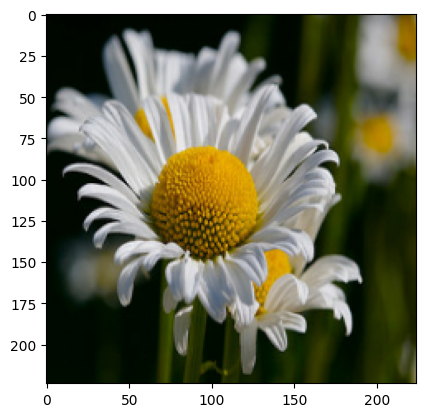

In [8]:
show_image('daisy/754296579_30a9ae018c_n.jpg')

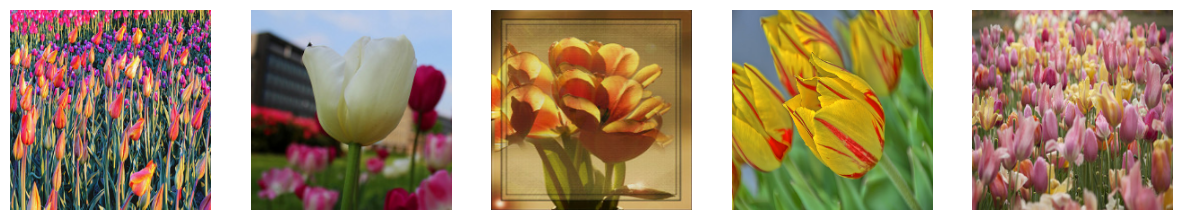

In [9]:
tulips = tf.io.gfile.glob(f'{IMG}/tulips/*.jpg')
_, ax = plt.subplots(1, 5, figsize=(15, 15))
for i, filename in enumerate(tulips[:5]):
    img = read_and_decode(filename, [IMG_H, IMG_W])
    ax[i].imshow((img.numpy()))
    ax[i].axis('off');

In [ ]:
list_ds = tf.data.Dataset.list_files(f'{IMG}/*/*', shuffle=False)
list_ds = list_ds.shuffle(nfiles, reshuffle_each_iteration=False)

In [ ]:
val_size = int(round(nfiles * 0.2))
train_ds = list_ds.skip(val_size)
val_ds = list_ds.take(val_size)

In [ ]:
def get_label(file_path):
  parts = tf.strings.split(file_path, os.path.sep)
  one_hot = parts[-2] == np.array(CLASS_NAMES)
  return tf.argmax(one_hot)

In [ ]:
def decode_img(img):
  # Convert the compressed string to a 3D uint8 tensor
  img = tf.io.decode_jpeg(img, channels=3)
  return tf.image.resize(img, [IMG_H, IMG_W])

In [ ]:
def process_path(file_path):
  label = get_label(file_path)
  # Load the raw data from the file as a string
  img = tf.io.read_file(file_path)
  img = decode_img(img)
  return img, label

In [ ]:
train_ds = train_ds.map(process_path)
val_ds = val_ds.map(process_path)

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    print(labels)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis('off')